# Pretprocesiranje podataka

**Koraci:** izvedeni atributi, čišćenje podataka, transformacija vrednosti atributa, standardizacija, smanjenje dimenzionalnosti i izbor podskupa atributa

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from collections import Counter

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from theme import *

In [2]:
Path("../plots/preprocessing").mkdir(parents=True, exist_ok=True)
Path("../models").mkdir(parents=True, exist_ok=True) # cuvamo istrenirane modele koje ce klasifikator samo da učita

Učitavanje originalnog skupa podataka

In [3]:
df = pd.read_csv("../data/trees10.csv")

## 1. Izvedeni atributi

**`ab_coverage`** = `ab_nodes_visited / total_nodes`: koliko je AB **stvarno** obišao, za razliku od `budget_coverage` koji je *nameravani* budžet kao udeo veličine stabla

**`mcts_unanimous`**: da li se svih 5 MCTS ponavljanja slaže (`mcts_correct_rate` je tačno 0 ili 1). Ovo je tačno mera koju smo izračunali u 01_eda (62.5% potpuno stabilno / 37.5% neizvesno)

**`depth_chance_inter`** = `depth × chance_node_density`: jeftina interakcija dve ose generatora, ista ideja kao `depth_chance_inter` u root-u.

**`is_tie`**: `which_better == "Tie"`: omogućava klasifikacionom notebook-u da bira između 3-klasnog `which_better` i binarnog AB-vs-MCTS jednom linijom.

**`tree_difficulty`**: koliko je stablo teško za algoritme uopšte: easy oba tačna, medium jedan tačan, hard nijedan tačan, izvodi se iz `which_algo`

In [4]:
df = df.copy()

df["ab_coverage"] = df["ab_nodes_visited"] / df["total_nodes"].clip(lower=1)
df["mcts_unanimous"] = ((df["mcts_correct_rate"] == 0) | (df["mcts_correct_rate"] == 1)).astype(int)
df["depth_chance_inter"] = df["depth"] * df["chance_node_density"]
df["is_tie"] = (df["which_better"] == "Tie").astype(int)

print(f"ab_coverage: mean={df['ab_coverage'].mean():.3f}, corr sa budget_coverage={df['ab_coverage'].corr(df['budget_coverage']):.3f}")
print(f"mcts_unanimous: {df['mcts_unanimous'].mean():.1%}")
print(f"is_tie: {df['is_tie'].sum()} od {len(df)} ({df['is_tie'].mean():.1%})")

ab_coverage: mean=0.201, corr sa budget_coverage=0.993
mcts_unanimous: 64.6%
is_tie: 5684 od 16978 (33.5%)


In [5]:
difficulty_map = {"Both": "easy", "AB": "medium", "MCTS": "medium", "Neither": "hard"}
df["tree_difficulty"] = df["which_algo"].map(difficulty_map)

df["tree_difficulty"].value_counts().reindex(["easy", "medium", "hard"])

tree_difficulty
easy      6203
medium    5330
hard      5445
Name: count, dtype: int64

## 2. Čišćenje podataka

### 2.1 Nedostajuće vrednosti

Provereno u EDA (01_eda.ipynb): dataset nema nedostajućih vrednosti

### 2.2 Detekcija autlajera

IQR metoda: vrednosti ispod `Q1 - 1.5*IQR` ili iznad `Q3 + 1.5*IQR`

In [6]:
outlier_cols = [
    "total_nodes", "leaf_value_std", "best_move_margin",
    "ab_pruning_rate", "mcts_vote_margin", "heur_incoherence"
]

rows = []
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum() 
    rows.append({
        "atribut": col,
        "Q1": round(Q1, 3), "Q3": round(Q3, 3), "IQR": round(IQR, 3),
        "broj_autlajera": n, "%": round(100 * n / len(df), 1)
    })

pd.DataFrame(rows).set_index("atribut")

,Q1,Q3,IQR,broj_autlajera,%
atribut,,,,,
total_nodes,278.000,7548.500,7270.500,1748,10.3
leaf_value_std,0.513,0.694,0.181,66,0.4
best_move_margin,0.066,0.349,0.283,855,5.0
ab_pruning_rate,0.000,0.108,0.108,2,0.0
mcts_vote_margin,0.028,0.236,0.208,1533,9.0
heur_incoherence,0.233,0.430,0.198,403,2.4


In [7]:
rows_sigma = []
for col in outlier_cols:
    mean, std = df[col].mean(), df[col].std()
    n = ((df[col] < mean - 3 * std) | (df[col] > mean + 3 * std)).sum()
    rows_sigma.append({"atribut": col, "broj_autlajera (3σ)": n, "%": round(100 * n / len(df), 1)})
    # tačke dalje od 3 std od medijane su autlajeri 

pd.DataFrame(rows_sigma).set_index("atribut")

,broj_autlajera (3σ),%
atribut,,
total_nodes,364,2.1
leaf_value_std,68,0.4
best_move_margin,328,1.9
ab_pruning_rate,11,0.1
mcts_vote_margin,346,2.0
heur_incoherence,197,1.2


Obe metode pokazuju nizak procenat autlajera. Autlajeri se **zadržavaju:** nisu greške merenja već realni ali retki slučajevi stabla (npr. stablo sa mnogo čvorova je validan parametar). Brisanje bi uklonilo informaciju relevantnu za klasifikaciju

## 3. Transformacija vrednosti atributa

### 3.1 Kodiranje kategorickih atributa

- `margin_category`i `tree_difficulty` su ordinalne ciljne promenljive - OrdinalEncoder sa redosledom kategorija
- `which_algo` i `which_better` su nominalne ciljne promenljive - LabelEncoder (redosled klasa nije bitan)

In [8]:
enc_margin = OrdinalEncoder(categories=[["low", "medium", "high"]])
df["margin_category_enc"] = enc_margin.fit_transform(df[["margin_category"]]).astype(int)

enc_diff = OrdinalEncoder(categories=[["easy", "medium", "hard"]])
df["tree_difficulty_enc"] = enc_diff.fit_transform(df[["tree_difficulty"]]).astype(int)

le = LabelEncoder()
df["which_algo_enc"] = le.fit_transform(df["which_algo"])
print("Kodiranje which_algo:", dict(zip(le.classes_, le.transform(le.classes_))))

le_better = LabelEncoder()
df["which_better_enc"] = le_better.fit_transform(df["which_better"])
print("Kodiranje which_better:", dict(zip(le_better.classes_, le_better.transform(le_better.classes_))))

Kodiranje which_algo: {'AB': np.int64(0), 'Both': np.int64(1), 'MCTS': np.int64(2), 'Neither': np.int64(3)}
Kodiranje which_better: {'AB': np.int64(0), 'MCTS': np.int64(1), 'Tie': np.int64(2)}


## 4. Standardizacija

z = (x - μ) / σ

Obavezno pre KNN, SVM i metoda zasnovanih na rastojanju. Scaler se cuva za primenu na test skupu u klasifikacionom notebooku

In [9]:
skip_scale = {
    "which_algo", "margin_category", "which_algo_enc",
    "which_better", "which_better_enc", "is_tie",
    "ab_correct", "mcts_correct", "mcts_correct_rate", "is_contested",
    "tree_difficulty", "tree_difficulty_enc", "margin_category_enc",
    "delta", "ab_regret", "mcts_regret",
}
feat_scale = [c for c in df.select_dtypes("number").columns if c not in skip_scale]

scaler = StandardScaler()
X_sc = scaler.fit_transform(df[feat_scale])

joblib.dump(scaler, "../models/scaler.pkl")
print(f"Skalirano {len(feat_scale)} atributa. Scaler sacuvan u ../models/scaler.pkl")

Skalirano 84 atributa. Scaler sacuvan u ../models/scaler.pkl


## 5. Smanjenje dimenzionalnosti

PCA i t-SNE vizualizacija uradjena u EDA (01_eda.ipynb): dimenzionalnost se ovde smanjuje izborom podskupa atributa

## 6. Izbor podskupa atributa

Tri grupe metoda: filter, wrapper i embedded. Svaka grupa daje jedan glas

Filter metode procenjuju atribute nezavisno od modela: korelacija i varijansa eliminisu lose kandidate, ANOVA skoruje preostale i bira top k. Wrapper i embedded zatim biraju nezavisno od istog skupa. Atribut ulazi u finalni skup ako ga izaberu bar dve od tri grupe

In [10]:
y = df["which_better_enc"].values
print(f"Broj atributa za izbor: {len(feat_scale)}")

Broj atributa za izbor: 84


### 6.1 Filter metode

Atributi se procenjuju nezavisno od modela. Svaki atribut dobija skor na osnovu statistickih svojstava ili mera slicnosti

**Metoda zasnovana na korelaciji** - uklanja jedan atribut iz para koji su medusobno visoko korelisani (|r| >= 0.99). Primenjuje se na neskaliranim podacima

**Metoda zasnovana na kvazi-konstantnosti** - uklanja atribute kod kojih jedna vrednost pokriva vise od 99% redova

**ANOVA F-test** (SelectKBest, f_classif) - statisticki test koji skoruje koliko dobro svaki atribut razdvaja klase. Bira top k od preostalih kandidata. Primenjuje se na skaliranim podacima

In [11]:
corr_df = df[feat_scale].corr().abs()
upper = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)) # gornji trougao (simetrična je)

to_drop_corr = [col for col in upper.columns if any(upper[col] >= 0.99)]
for col in to_drop_corr:
    partner = upper[col][upper[col] >= 0.99].index[0]
    print(f"Brisem: {col}  (korelacija sa {partner}: {corr_df.loc[col, partner]:.3f})")

feat_after_corr = [f for f in feat_scale if f not in to_drop_corr]
print(f"\nKorelaciona metoda: {len(feat_scale)} -> {len(feat_after_corr)} atributa")

Brisem: total_leaves  (korelacija sa total_nodes: 0.995)
Brisem: leaf_to_internal_ratio  (korelacija sa branching_factor: 0.994)
Brisem: branching_mean  (korelacija sa branching_factor: 0.994)
Brisem: realized_max_depth  (korelacija sa depth: 1.000)
Brisem: leaf_depth_mean  (korelacija sa depth: 1.000)
Brisem: leaf_fraction_positive  (korelacija sa leaf_value_mean: 0.991)
Brisem: branching_mean_d1  (korelacija sa leaf_to_internal_ratio: 0.993)
Brisem: ab_nodes_visited  (korelacija sa node_budget: 1.000)
Brisem: best_move_margin_normalized  (korelacija sa best_move_margin: 0.998)
Brisem: ab_coverage  (korelacija sa budget_coverage: 0.993)

Korelaciona metoda: 84 -> 74 atributa


In [12]:
QC_THRESHOLD = 0.99
dominant = df[feat_after_corr].apply(lambda s: s.value_counts(normalize=True).iloc[0])
to_drop_qc = dominant[dominant > QC_THRESHOLD].index.tolist()

for col in to_drop_qc:
    print(f"Brisem: {col}  (jedna vrednost pokriva {dominant[col]:.1%} redova)")

feat_after_vt = [f for f in feat_after_corr if f not in to_drop_qc]
print(f"\nKvazi-konstantni: {len(feat_after_corr)} -> {len(feat_after_vt)} atributa")


Kvazi-konstantni: 74 -> 74 atributa


In [13]:
idx = [feat_scale.index(f) for f in feat_after_vt]
X_vt = X_sc[:, idx] # skalirani podaci!

sel = SelectKBest(f_classif, k=len(feat_after_vt) // 2)
sel.fit(X_vt, y)
feat_anova = [feat_after_vt[i] for i in range(len(feat_after_vt)) if sel.get_support()[i]]
print(f"ANOVA F-test (top {len(feat_after_vt) // 2}): {len(feat_anova)} atributa")

ANOVA F-test (top 37): 37 atributa


### 6.2 Wrapper metode

Model se vise puta trenira sa razlicitim podskupovima atributa. Kvalitet podskupa se meri na osnovu performansi modela

**RFE** (Recursive Feature Elimination): iterativno uklanja atribut koji model smatra najmanje vaznim, dok ne ostane zeljeni broj atributa

In [14]:
rfe = RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=len(feat_after_vt) // 2)
rfe.fit(X_vt, y)
feat_rfe = [feat_after_vt[i] for i in range(len(feat_after_vt)) if rfe.support_[i]]
print(f"RFE: {len(feat_after_vt)} -> {len(feat_rfe)} atributa")

RFE: 74 -> 37 atributa


### 6.3 Embedded metode

Izbor atributa se vrsi tokom samog treniranja modela

**Random Forest:** racuna vaznost atributa na osnovu Ginijevog indeksa (koliko svaki atribut doprinosi čistoci čvorova stabla tokom treniranja)

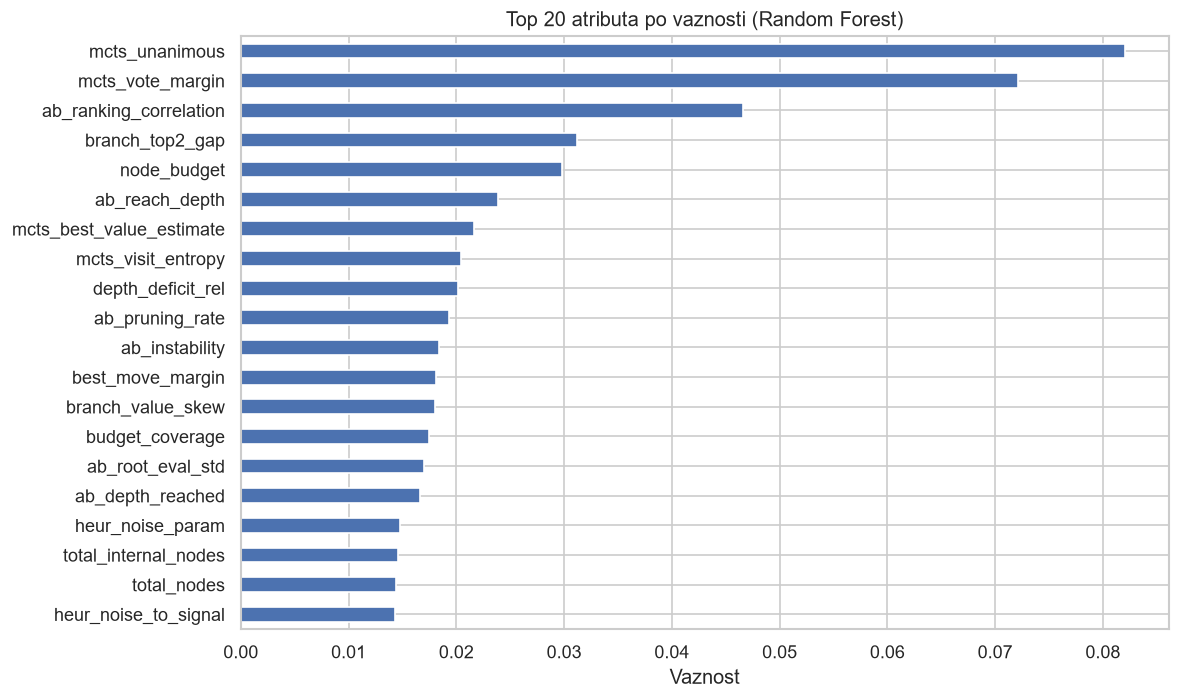

Random Forest (top 37): 37 atributa


In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_vt, y)

importances = pd.Series(rf.feature_importances_, index=feat_after_vt).sort_values(ascending=False)
feat_rf = importances.head(len(feat_after_vt) // 2).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(20).sort_values().plot.barh(ax=ax, color=POS_COLOR)
ax.set_title("Top 20 atributa po vaznosti (Random Forest)", fontsize=12)
ax.set_xlabel("Vaznost")
plt.tight_layout()
plt.savefig("../plots/preprocessing/rf_importance.png", bbox_inches="tight")
plt.show()
print(f"Random Forest (top {len(feat_after_vt) // 2}): {len(feat_rf)} atributa")

### 6.4 Presek metoda

Ansambl izbor atributa: svaka grupa daje jedan glas, atribut ulazi u finalni skup ako ga izaberu bar 2 od 3 grupe (filter, wrapper, embedded). 


In [16]:
all_selected = feat_anova + feat_rfe + feat_rf 
counts = Counter(all_selected)
feat_final = sorted(f for f, cnt in counts.items() if cnt >= 2)

print(f"Finalni skup (>= 2 od 3 grupe): {len(feat_final)} atributa")

pd.DataFrame({
    "ANOVA (filter)": [f in feat_anova for f in feat_final],
    "RFE (wrapper)": [f in feat_rfe for f in feat_final],
    "RF (embedded)": [f in feat_rf for f in feat_final],
    "ukupno glasova": [counts[f] for f in feat_final]
}, index=feat_final)

Finalni skup (>= 2 od 3 grupe): 33 atributa


,ANOVA (filter),RFE (wrapper),RF (embedded),ukupno glasova
ab_depth_reached,True,True,True,3
ab_instability,True,True,True,3
ab_pruning_rate,True,True,True,3
ab_ranking_correlation,True,True,True,3
ab_reach_depth,True,True,True,3
ab_root_eval_std,False,True,True,2
best_move_margin,True,True,True,3
branch_mean_spread,False,True,True,2
branch_top2_gap,True,True,True,3
branch_value_skew,True,False,True,2


Finalni pretprocesirani skup za klasifikaciju (03_classification.ipynb)

In [17]:
target_cols = [
    "which_algo", "which_algo_enc",
    "which_better", "which_better_enc", "is_tie",
    "ab_correct", "mcts_correct", "mcts_correct_rate",
    "is_contested", "margin_category", "margin_category_enc",
    "tree_difficulty", "tree_difficulty_enc",
    "delta", "ab_regret", "mcts_regret",
]
save_cols = feat_final + [c for c in target_cols if c in df.columns]

df[save_cols].to_csv("../data/trees_preprocessed.csv", index=False)
print(f"Sacuvano: {len(df)} slogova, {len(feat_final)} atributa + {len([c for c in target_cols if c in df.columns])} ciljnih kolona")
print(f"-> ../data/trees_preprocessed.csv")

Sacuvano: 16978 slogova, 33 atributa + 16 ciljnih kolona
-> ../data/trees_preprocessed.csv
